In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
print("Original shape:",X.shape)

Original shape: (150, 4)


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
cov_matrix = np.cov(X_scaled.T)

In [6]:
print(cov_matrix)


[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [13]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
sorted_index = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:,sorted_index]
print(sorted_eigenvalues)

[2.93808505 0.9201649  0.14774182 0.02085386]


In [14]:
print(sorted_eigenvectors)

[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [10]:
n_components =2
principal_components = sorted_eigenvectors[:,:n_components]
print("Top 2 principal components\n",principal_components)

Top 2 principal components
 [[ 0.52106591 -0.37741762]
 [-0.26934744 -0.92329566]
 [ 0.5804131  -0.02449161]
 [ 0.56485654 -0.06694199]]


In [11]:
X_pca = X_scaled.dot(principal_components)
print("Transformed Data shape",X_pca.shape)

Transformed Data shape (150, 2)


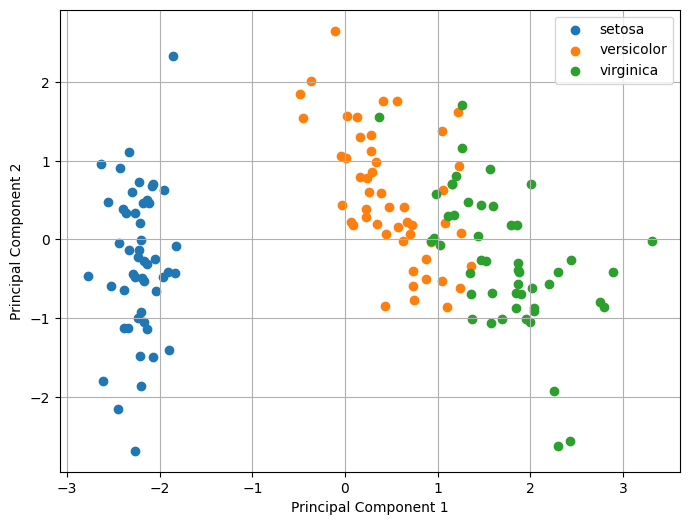

In [12]:
plt.figure(figsize=(8,6))
for i in range(3):
  plt.scatter(
      X_pca[y==i,0],
      X_pca[y==i,1],
      label=iris.target_names[i]
  )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()